In [16]:
# Importing modules
from nltk.corpus import stopwords
from gensim.utils import simple_preprocess
import spacy
import gensim
import re
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
#import seaborn
import os
#import os as sns
import nltk
# Ensure necessary NLTK datasets are downloaded
#nltk.download('stopwords')

# File path for your CSV
file_path = r'K:\Factors_Extraction_Data_2.csv'
df = pd.read_csv(file_path)

# Handle missing values by filling them with empty strings
df['Original Statement'] = df['Original Statement'].fillna('')

# Remove punctuation and convert text to lowercase
df['Original Statement'] = df['Original Statement'].apply(lambda x: re.sub('[,\.!?]', '', str(x).lower()))

# Print out the first few rows of the processed column for quick verification
print(df['Original Statement'].head())

# Assuming 'Verbal_Report_corrected' is another column containing textual data.
data = df['Original Statement']

# Build bigrams and trigrams capture word patterns and common expressions
bigram = gensim.models.Phrases(data, min_count=20, threshold=100)
trigram = gensim.models.Phrases(bigram[data], threshold=100)
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# Use only the tagger in Spacy for faster processing A spaCy NLP model is loaded (`en_core_web_sm`) with the parser and named entity recognizer disabled. This speeds up processing when POS tagging and lemmatization are primarily required
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Define stopwords using NLTK
stop_words = set(stopwords.words('english'))
#The text is lemmatized using spaCy, which reduces words to their base form while retaining specific parts of speech tags (`NOUN`, `ADJ`, `VERB`, `ADV`).
def process_words(texts, stop_words=stop_words, allowed_tags=['NOUN', 'ADJ', 'VERB', 'ADV']): #A custom function `process_words()` is defined to process the text
    """Convert a document into a list of lowercase tokens, build bigrams-trigrams, implement lemmatization."""
    # Remove stopwords, short tokens, and letter accents
    texts = [[word for word in simple_preprocess(str(doc), deacc=True, min_len=3) if word not in stop_words] for doc in texts]

    texts_out = []
    
    # Implement lemmatization and filter out unwanted parts of speech tags, Another round of stopword removal and punctuation removal is conducted post-lemmatization
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_tags])
    
    # Remove stopwords and short tokens again after lemmatization
    texts_out = [[word for word in simple_preprocess(str(doc), deacc=True, min_len=3) if word not in stop_words] for doc in texts_out]
    
    return texts_out

# Process your text data
data_ready = process_words(data)

0    you call them and they leave you waiting for m...
1    and if they do answer it's impossible to solve...
2    every time someone tries to transfer money the...
3    i went to the nearest bank near me and didn't ...
4    he told me to come back the next day so i did ...
Name: Original Statement, dtype: object


In [17]:
from nltk import pos_tag
from collections import Counter
def preprocess_and_extract_nouns(doc):
    # POS tagging to extract nouns
    tagged_words = pos_tag(doc) #Use `pos_tag` from NLTK to perform part-of-speech tagging on the document
    
    # Extract nouns (NN, NNS, NNP, NNPS are common noun tags)
    nouns = [word for word, pos in tagged_words if pos in ['NN', 'NNS', 'NNP', 'NNPS']] # Identify and extract words tagged as nouns, which include:
    #- `'NN'`: Noun, singular or mass - `'NNS'`: Noun, plural - `'NNP'`: Proper noun, singular - `'NNPS'`: Proper noun, plural
     # Return the list of extracted nouns.
    return nouns

# Since data_ready already contains tokenized documents,
# just apply the noun extraction directly.
#The noun extraction function is applied to each document in `data_ready`, storing the results in a new column `'Nouns'` in the `df` DataFrame.
# `data_ready` is presumed to contain lists of tokenized and processed words from the input documents.
df['Nouns'] = [preprocess_and_extract_nouns(doc) for doc in data_ready]

# Flatten the list of nouns and count frequency
#Flattening: Combine the lists of nouns into a single list (`all_nouns`).
all_nouns = sum(df['Nouns'].tolist(), [])  # Flatten list of lists
noun_freq = Counter(all_nouns) #counting: Use Python's `Counter` from the `collections` module to count the frequency of each noun

# Calculate total number of nouns for percentage calculations
total_nouns = sum(noun_freq.values())

# Prepare results with frequency and percentage
noun_stats = [(noun, freq, (freq / total_nouns) * 100) for noun, freq in noun_freq.most_common()]

# Convert results to a DataFrame for better display
noun_freq_df = pd.DataFrame(noun_stats, columns=['Noun', 'Frequency', 'Percentage'])

# Display the top nouns by frequency
print(noun_freq_df.sort_values(by='Frequency', ascending=False).head(100))

# Display the top nouns by frequency
top_nouns_df = noun_freq_df.sort_values(by='Frequency', ascending=False).head(100)
print(top_nouns_df)

# Save the result to an Excel file
output_file_path = 'K:/Service delay risk.xlsx'  # Specify your desired file path and name
top_nouns_df.to_excel(output_file_path, index=False, sheet_name='TopNouns')

print(f"Top nouns by frequency have been saved to {output_file_path}")

        Noun  Frequency  Percentage
0       time        334    3.414784
1        app        323    3.302321
2       bank        291    2.975156
3    account        276    2.821797
4      money        239    2.443513
..       ...        ...         ...
95       fee         19    0.194254
96    people         18    0.184030
97      list         18    0.184030
98      step         18    0.184030
99  download         18    0.184030

[100 rows x 3 columns]
        Noun  Frequency  Percentage
0       time        334    3.414784
1        app        323    3.302321
2       bank        291    2.975156
3    account        276    2.821797
4      money        239    2.443513
..       ...        ...         ...
95       fee         19    0.194254
96    people         18    0.184030
97      list         18    0.184030
98      step         18    0.184030
99  download         18    0.184030

[100 rows x 3 columns]
Top nouns by frequency have been saved to K:/Service delay risk.xlsx


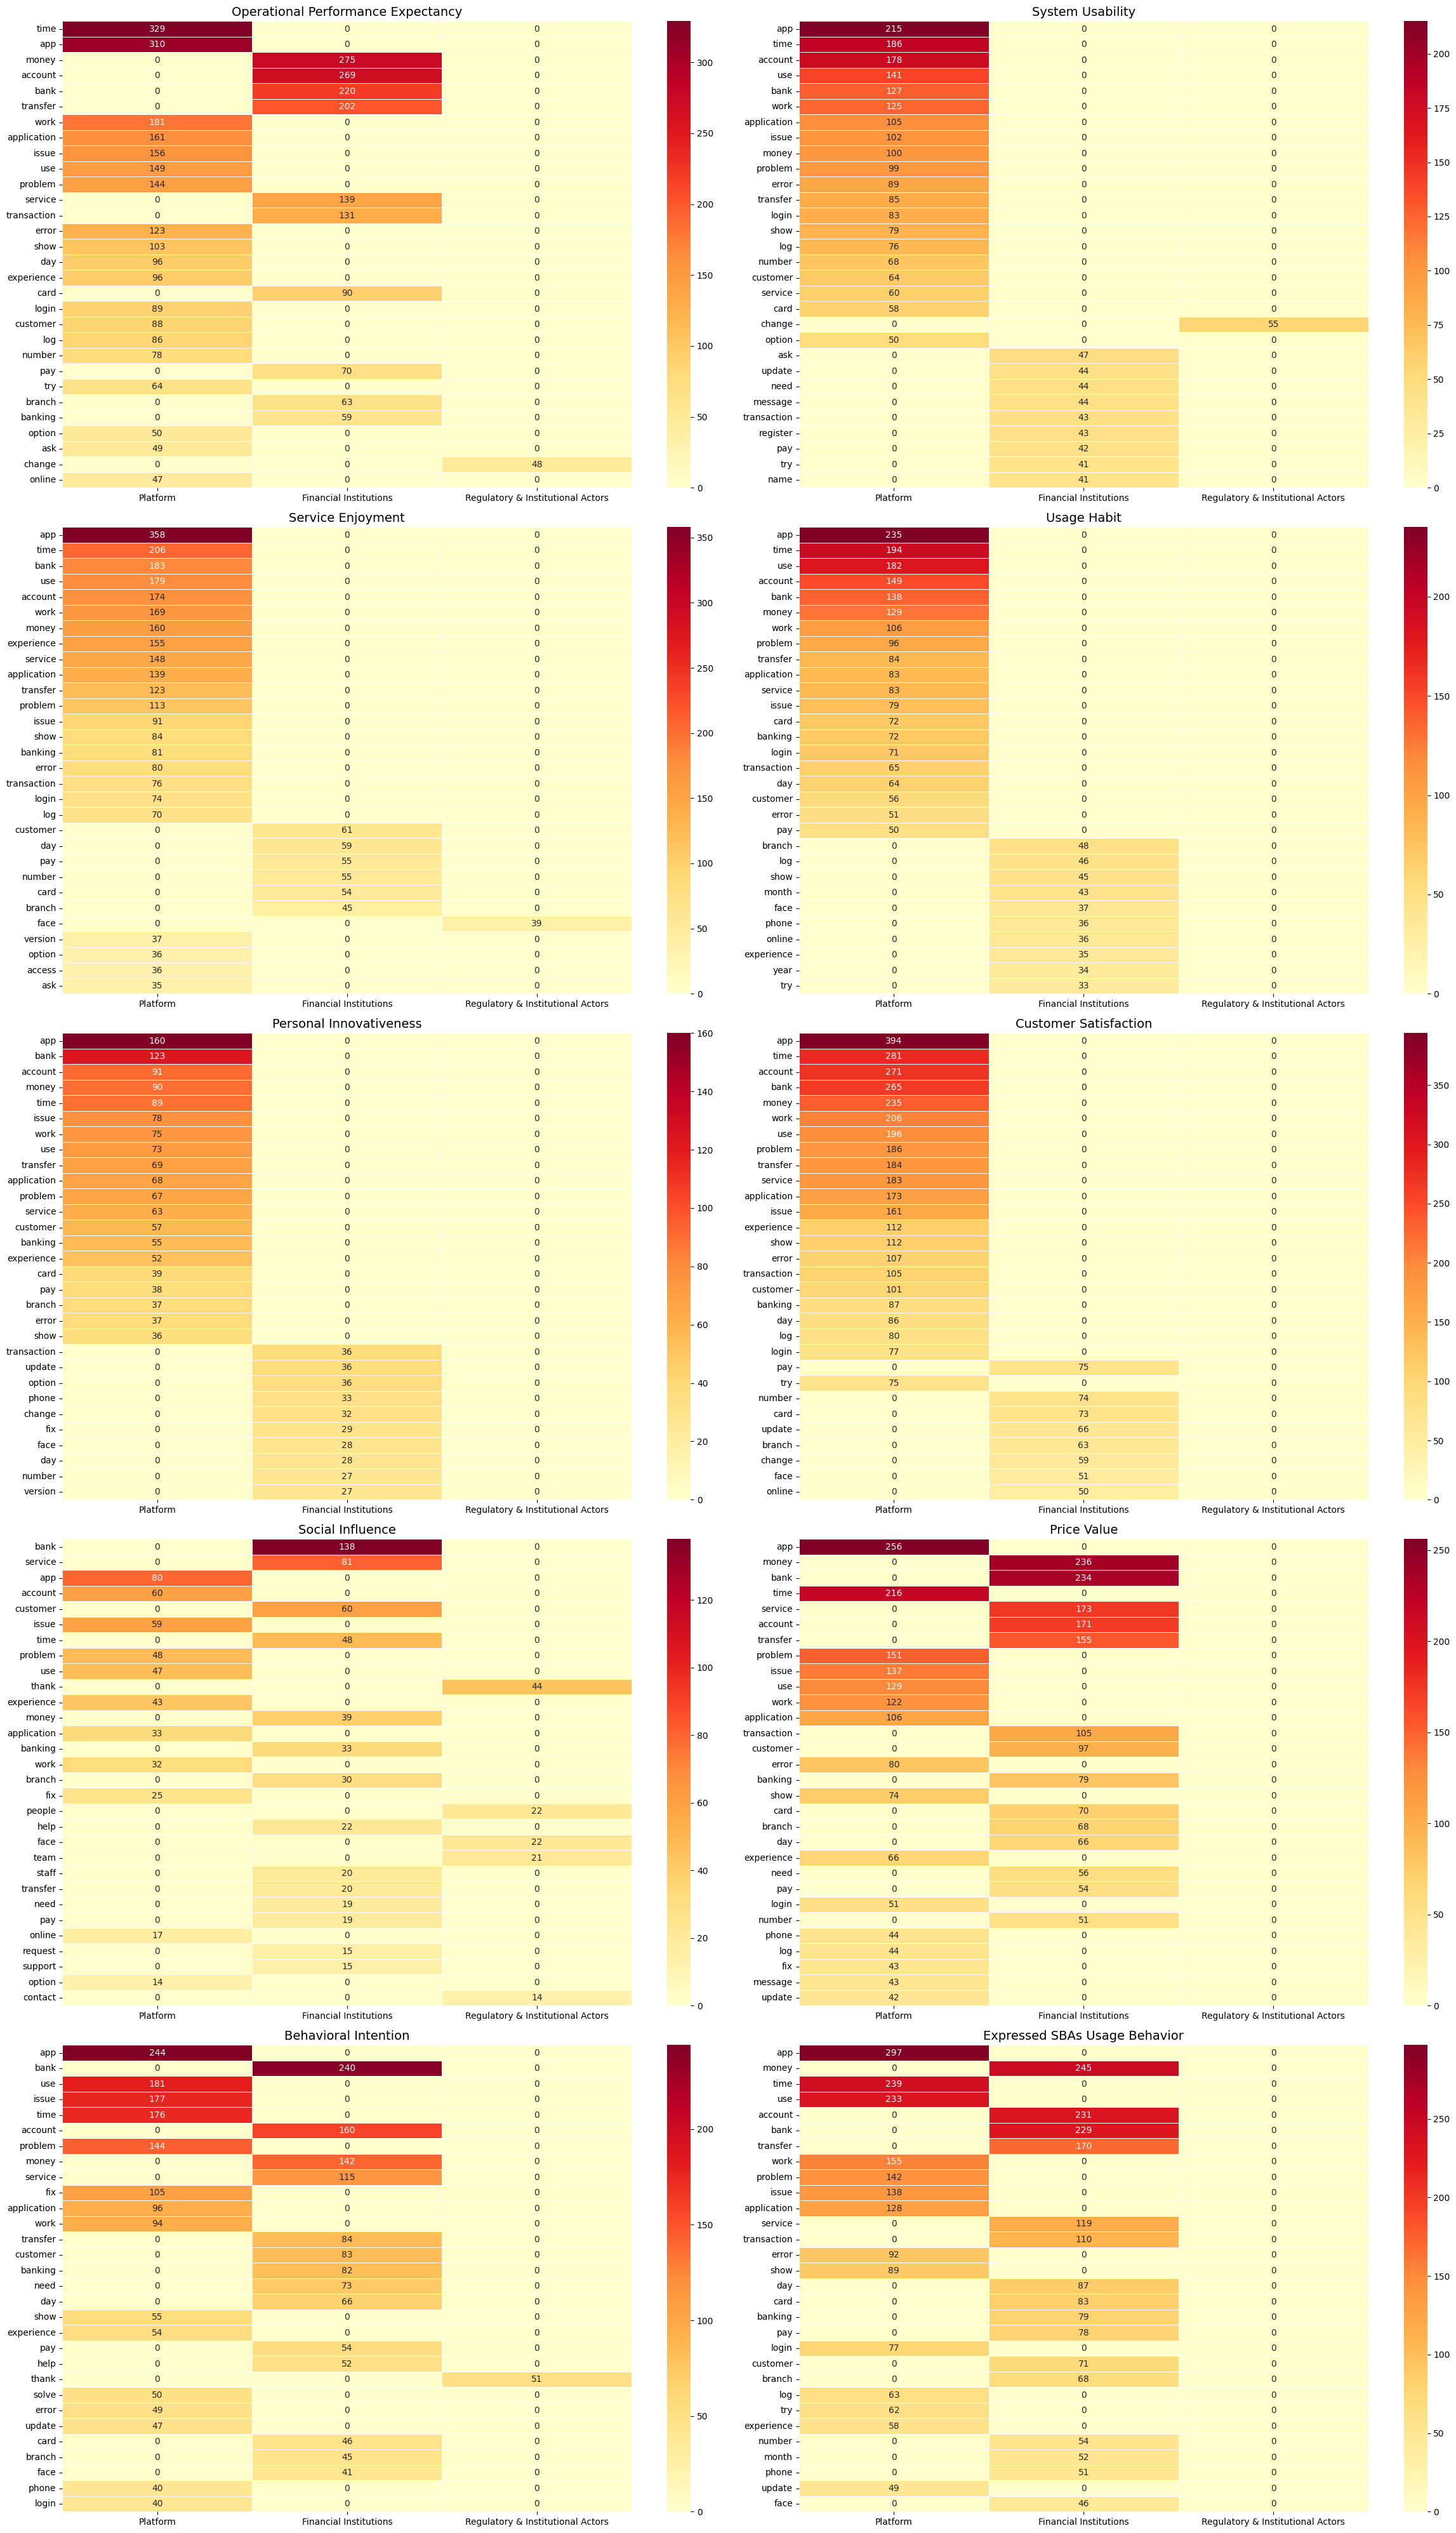

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

file_path = r"K:\Heat_Map_v1.xlsx"

# Read without assuming headers
raw = pd.read_excel(file_path, header=None)

# Find the row that contains repeated "Sr.No"
srno_row = None
for i in range(len(raw)):
    row_values = raw.iloc[i].astype(str).str.strip().str.lower()
    if (row_values == "sr.no").sum() >= 3:
        srno_row = i
        break

if srno_row is None:
    raise ValueError("Could not find the header row containing Sr.No")

# Construct names are usually one row above Sr.No
construct_row = srno_row - 1

# Find starting columns of each construct block
srno_cols = [
    col for col in raw.columns
    if str(raw.iloc[srno_row, col]).strip().lower() == "sr.no"
]

long_parts = []

for idx, start_col in enumerate(srno_cols):
    end_col = srno_cols[idx + 1] if idx + 1 < len(srno_cols) else raw.shape[1]

    construct = str(raw.iloc[construct_row, start_col]).strip()
    if construct == "nan" or construct == "":
        construct = f"Construct_{idx+1}"

    block = raw.iloc[srno_row + 1:, start_col:end_col].copy()

    # Keep only first 5 columns if extra blank columns exist
    block = block.iloc[:, :5]

    # If block has fewer than 5 columns, skip it
    if block.shape[1] < 5:
        print(f"Skipping {construct}: only {block.shape[1]} columns found")
        continue

    block.columns = ["Sr.No", "Actor", "Noun", "Frequency", "Percentage"]
    block["Construct"] = construct

    long_parts.append(block)

df = pd.concat(long_parts, ignore_index=True)

# Clean
df = df.dropna(subset=["Noun", "Frequency"])
df["Actor"] = df["Actor"].astype(str).str.strip()
df["Noun"] = df["Noun"].astype(str).str.strip()
df["Construct"] = df["Construct"].astype(str).str.strip()
df["Frequency"] = pd.to_numeric(df["Frequency"], errors="coerce")
df = df.dropna(subset=["Frequency"])

# Standardize actor labels
actor_map = {
    "platform": "Platform",
    "financial institutions": "Financial Institutions",
    "financial institution": "Financial Institutions",
    "financial i": "Financial Institutions",
    "regulatory and institutional actors": "Regulatory & Institutional Actors",
    "regulatory & institutional actors": "Regulatory & Institutional Actors"
}

df["Actor_std"] = df["Actor"].str.lower().map(actor_map).fillna(df["Actor"])

all_actors = [
    "Platform",
    "Financial Institutions",
    "Regulatory & Institutional Actors"
]

# Plot heatmaps
TOP_N = 30
constructs = df["Construct"].unique()

cols = 2
rows = math.ceil(len(constructs) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 8))
axes = axes.flatten()

for i, construct in enumerate(constructs):
    ax = axes[i]

    subset = df[df["Construct"] == construct]

    top_nouns = (
        subset.groupby("Noun")["Frequency"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
    )

    subset = subset[subset["Noun"].isin(top_nouns)]

    mat = subset.pivot_table(
        index="Noun",
        columns="Actor_std",
        values="Frequency",
        aggfunc="sum",
        fill_value=0
    )

    mat = mat.reindex(columns=all_actors, fill_value=0)
    mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

    sns.heatmap(
        mat,
        cmap="YlOrRd",
        linewidths=0.4,
        linecolor="white",
        annot=True,
        fmt=".0f",
        cbar=True,
        ax=ax
    )

 #   ax.set_title(construct, fontsize=14, fontweight="bold")
    ax.set_title(construct, fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

#plt.suptitle(
#    "Actor–Noun Heatmaps Across Constructs",
#    fontsize=20,
 #   fontweight="bold",
 #   y=1.02
#)

plt.tight_layout()

plt.savefig(r"K:\All_Constructs_Heatmaps.png", dpi=600, bbox_inches="tight")
plt.savefig(r"K:\All_Constructs_Heatmaps.pdf", bbox_inches="tight")

plt.show()

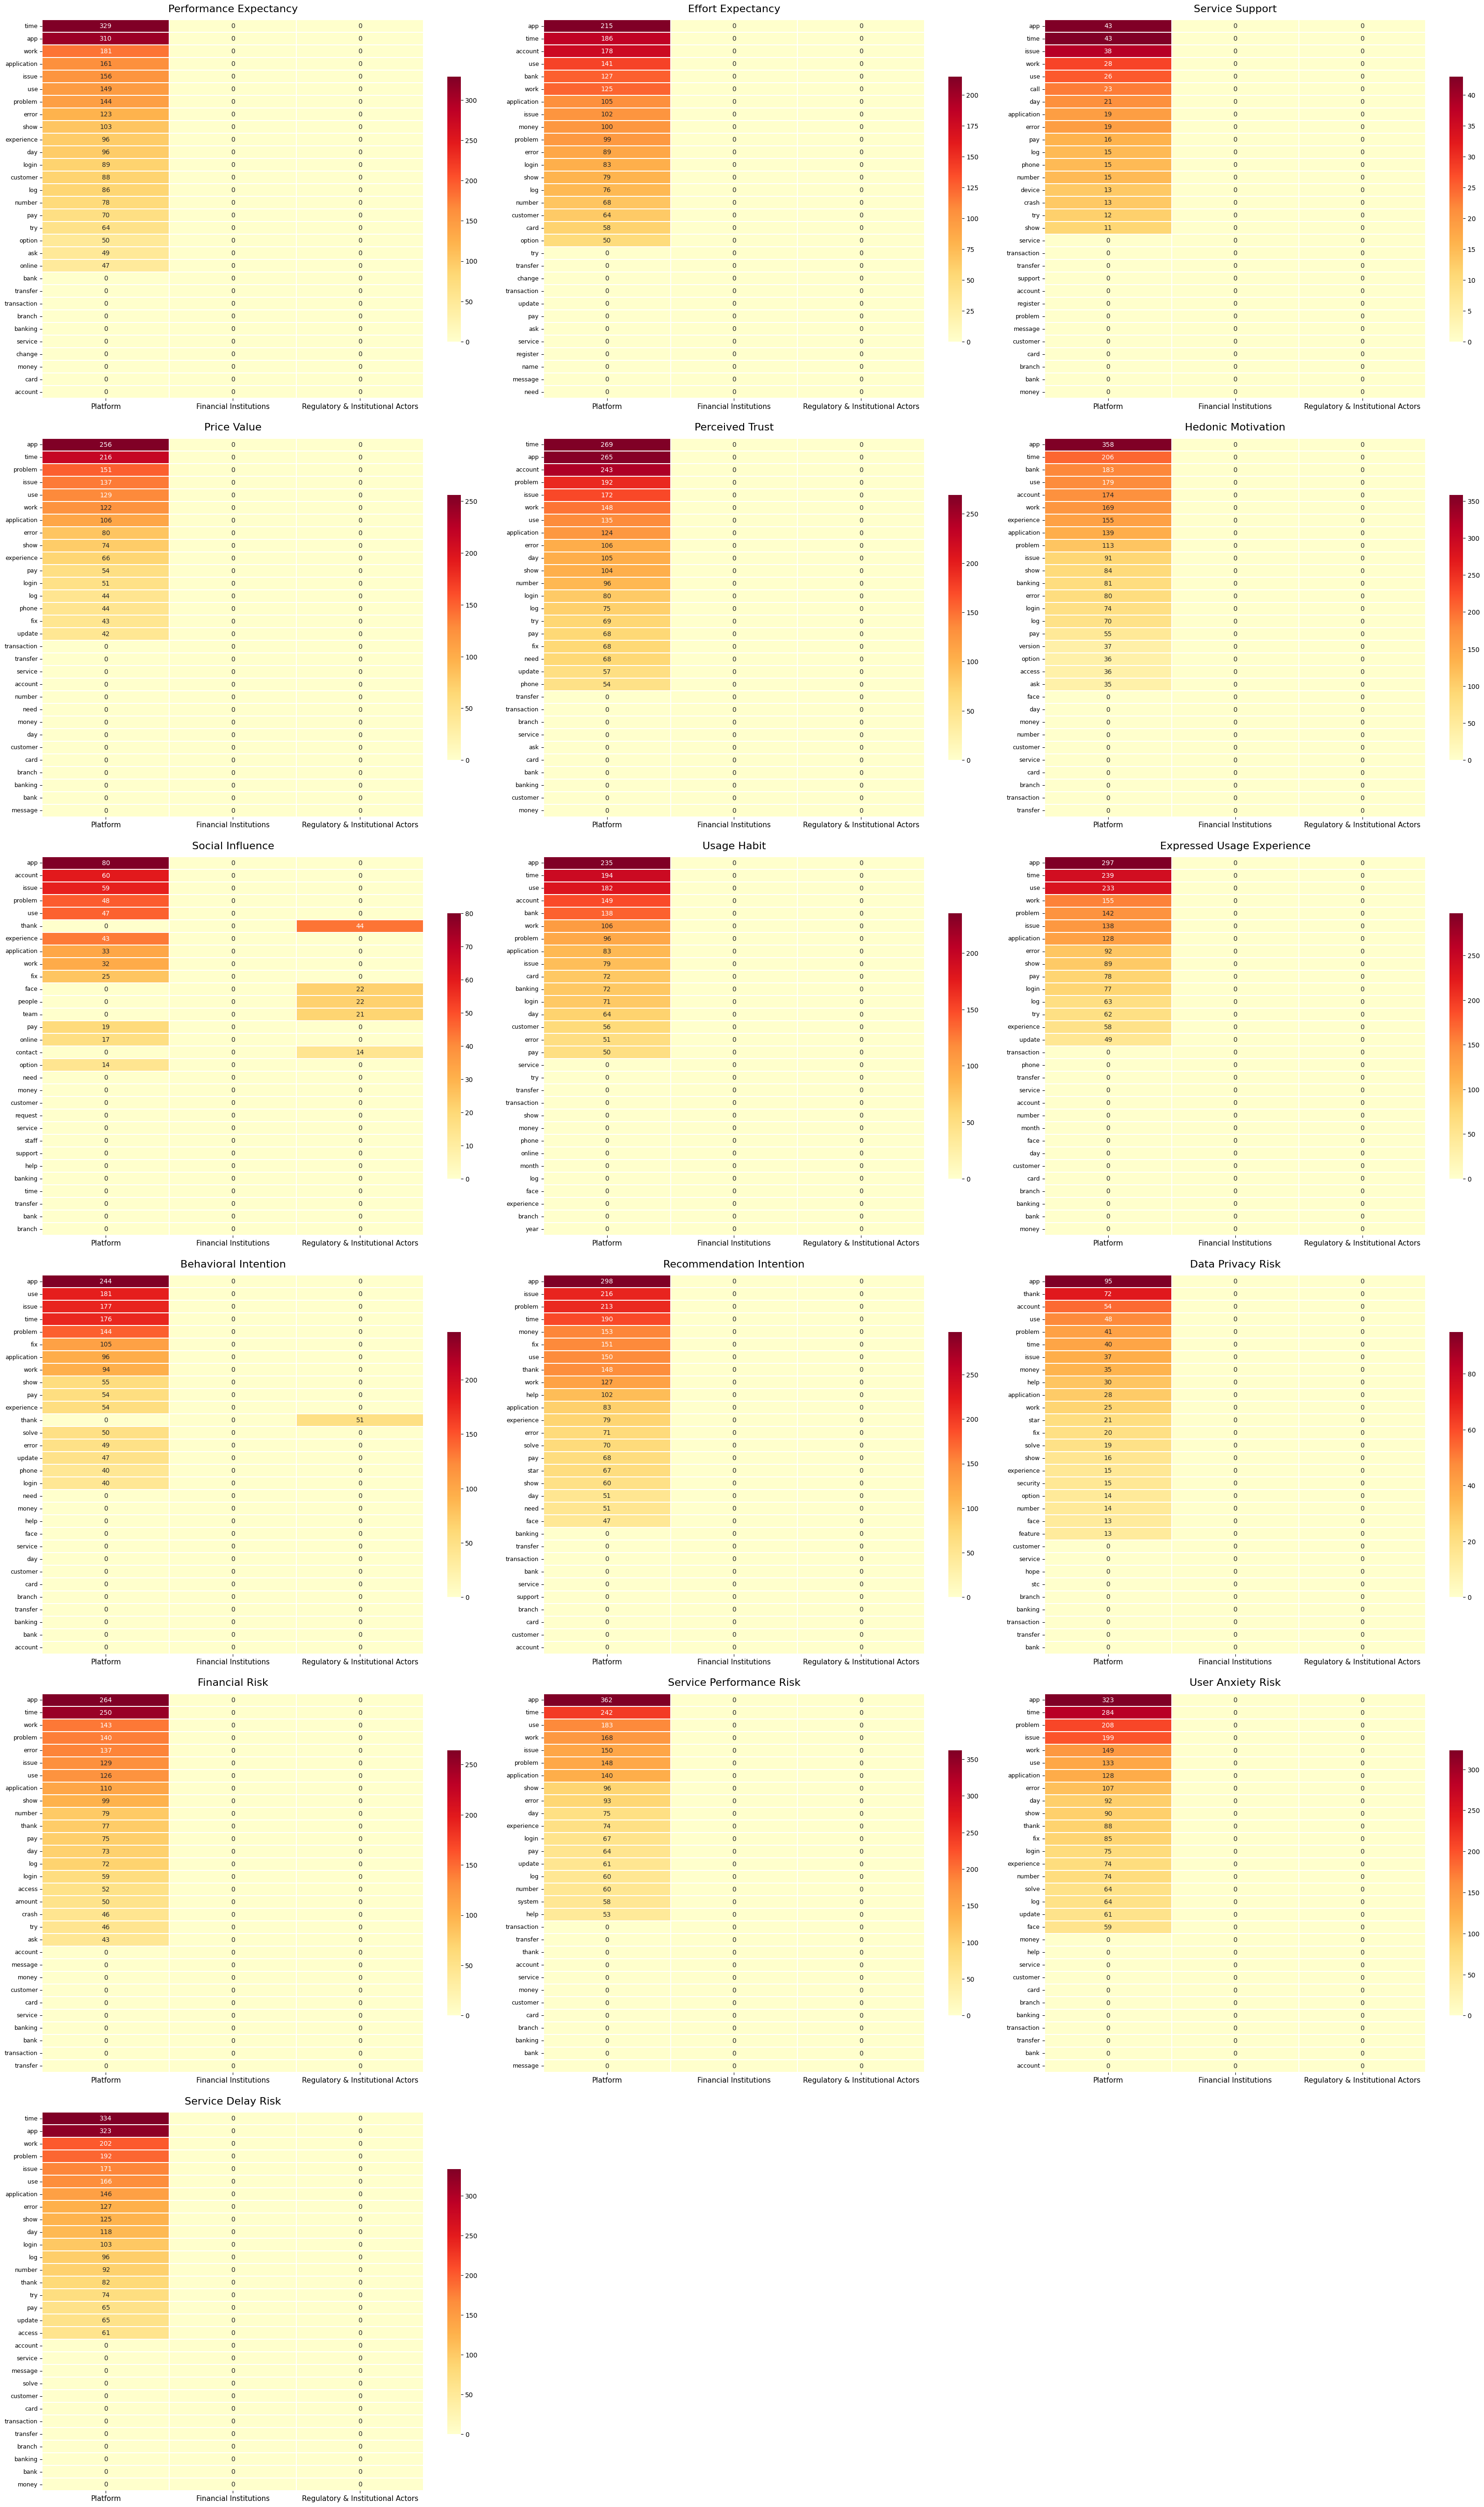

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

file_path = r"K:\Heat_Map_v1.xlsx"

raw = pd.read_excel(file_path, header=None)

# Find header row
srno_row = None
for i in range(len(raw)):
    row_values = raw.iloc[i].astype(str).str.strip().str.lower()
    if (row_values == "sr.no").sum() >= 3:
        srno_row = i
        break

if srno_row is None:
    raise ValueError("Could not find the header row containing Sr.No")

construct_row = srno_row - 1

srno_cols = [
    col for col in raw.columns
    if str(raw.iloc[srno_row, col]).strip().lower() == "sr.no"
]

long_parts = []

for idx, start_col in enumerate(srno_cols):
    end_col = srno_cols[idx + 1] if idx + 1 < len(srno_cols) else raw.shape[1]

    construct = str(raw.iloc[construct_row, start_col]).strip()
    if construct == "nan" or construct == "":
        construct = f"Construct_{idx + 1}"

    block = raw.iloc[srno_row + 1:, start_col:end_col].copy()
    block = block.iloc[:, :5]

    if block.shape[1] < 5:
        print(f"Skipping {construct}: only {block.shape[1]} columns found")
        continue

    block.columns = ["Sr.No", "Actor", "Noun", "Frequency", "Percentage"]
    block["Construct"] = construct
    long_parts.append(block)

df = pd.concat(long_parts, ignore_index=True)

# Clean data
df = df.dropna(subset=["Noun", "Frequency"])
df["Actor"] = df["Actor"].astype(str).str.strip()
df["Noun"] = df["Noun"].astype(str).str.strip()
df["Construct"] = df["Construct"].astype(str).str.strip()
df["Frequency"] = pd.to_numeric(df["Frequency"], errors="coerce")
df = df.dropna(subset=["Frequency"])

# Standardize actor labels
actor_map = {
    "platform": "Platform",
    "financial institutions": "Financial Institutions",
    "financial institution": "Financial Institutions",
    "financial i": "Financial Institutions",
    "regulatory and institutional actors": "Regulatory & Institutional Actors",
    "regulatory & institutional actors": "Regulatory & Institutional Actors"
}

df["Actor_std"] = df["Actor"].str.lower().map(actor_map).fillna(df["Actor"])

all_actors = ["Platform", "Financial Institutions", "Regulatory & Institutional Actors"]

# Plot heatmaps
TOP_N = 30
constructs = df["Construct"].unique()

cols = 3
rows = math.ceil(len(constructs) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(33, rows * 9)
)

axes = axes.flatten()

for i, construct in enumerate(constructs):
    ax = axes[i]

    subset = df[df["Construct"] == construct]

    top_nouns = (
        subset.groupby("Noun")["Frequency"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
    )

    subset = subset[subset["Noun"].isin(top_nouns)]

    mat = subset.pivot_table(
        index="Noun",
        columns="Actor_std",
        values="Frequency",
        aggfunc="sum",
        fill_value=0
    )

    mat = mat.reindex(columns=all_actors, fill_value=0)
    mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

    sns.heatmap(
        mat,
        cmap="YlOrRd",
        linewidths=0.3,
        linecolor="white",
        annot=True,
        fmt=".0f",
        cbar=True,
        cbar_kws={"shrink": 0.7},
        ax=ax
    )

    ax.set_title(construct, fontsize=16, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        ha="center",
        fontsize=11
    )

    ax.tick_params(axis="y", labelsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=2)

plt.savefig(
    r"K:\All_Constructs_Heatmaps_Landscape.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    r"K:\All_Constructs_Heatmaps_Landscape.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

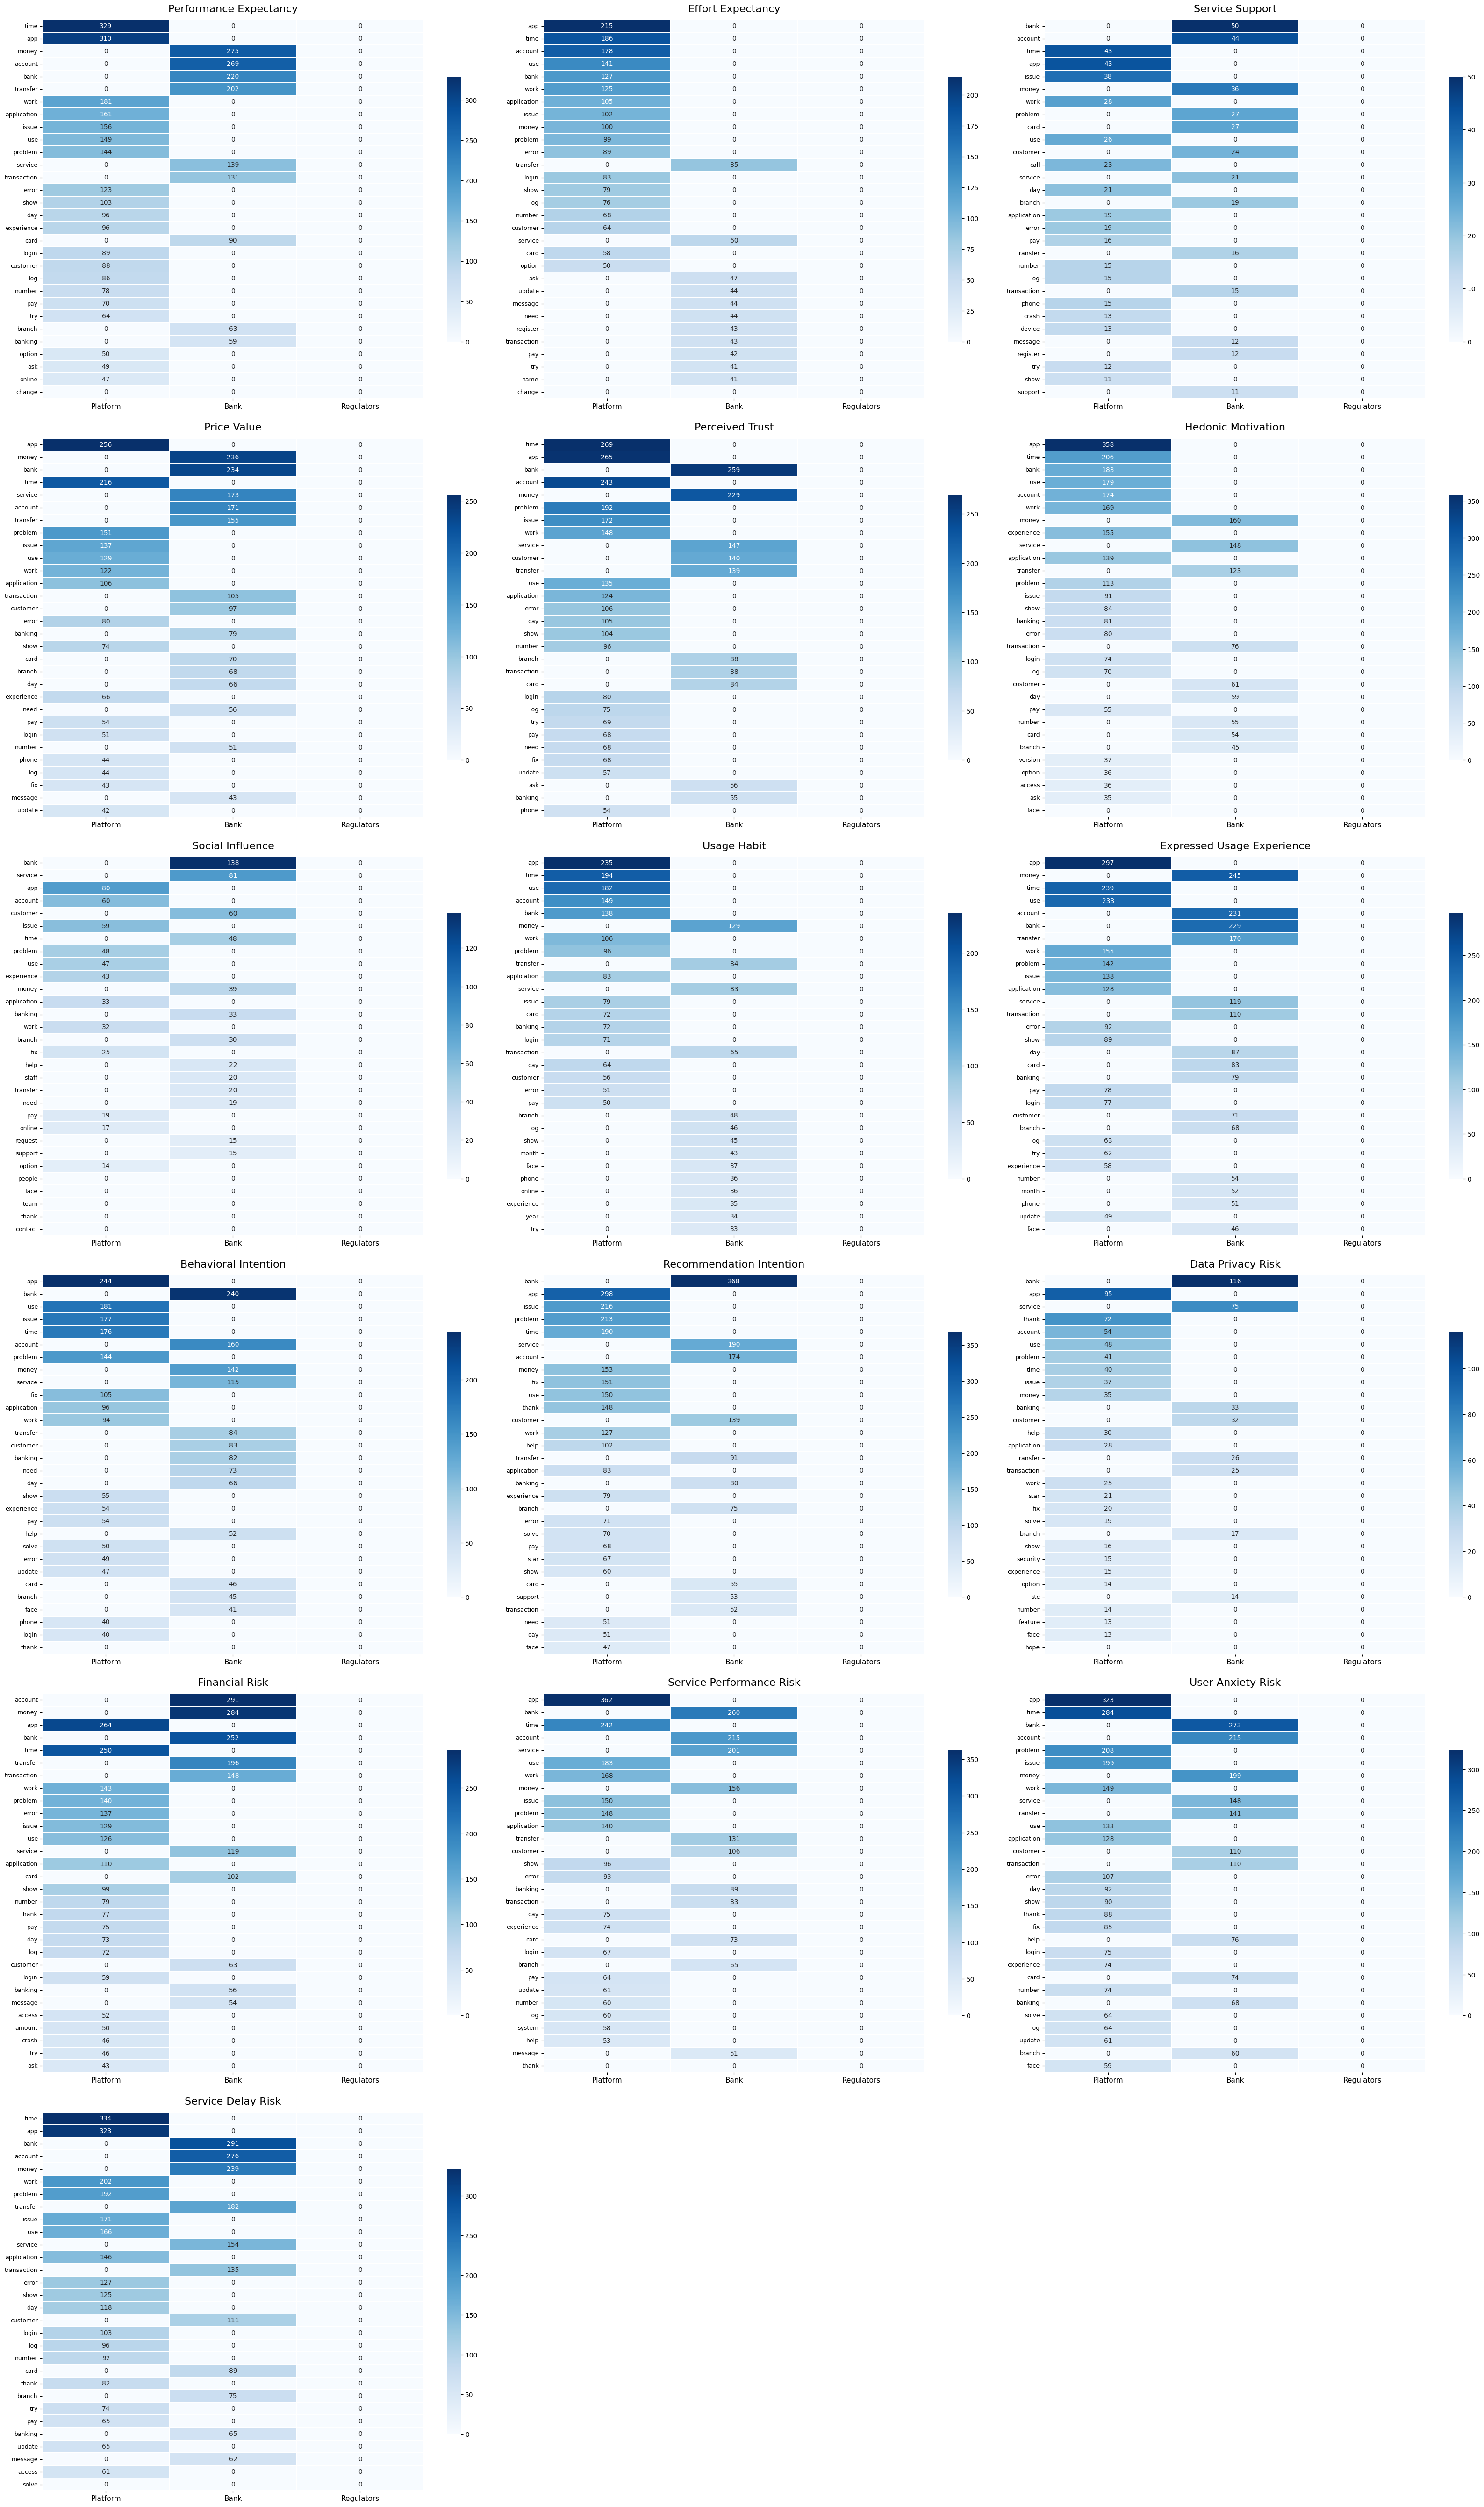

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

file_path = r"K:\Heat_Map_v1.xlsx"

raw = pd.read_excel(file_path, header=None)

# Find header row
srno_row = None
for i in range(len(raw)):
    row_values = raw.iloc[i].astype(str).str.strip().str.lower()
    if (row_values == "sr.no").sum() >= 3:
        srno_row = i
        break

if srno_row is None:
    raise ValueError("Could not find the header row containing Sr.No")

construct_row = srno_row - 1

srno_cols = [
    col for col in raw.columns
    if str(raw.iloc[srno_row, col]).strip().lower() == "sr.no"
]

long_parts = []

for idx, start_col in enumerate(srno_cols):
    end_col = srno_cols[idx + 1] if idx + 1 < len(srno_cols) else raw.shape[1]

    construct = str(raw.iloc[construct_row, start_col]).strip()
    if construct == "nan" or construct == "":
        construct = f"Construct_{idx + 1}"

    block = raw.iloc[srno_row + 1:, start_col:end_col].copy()
    block = block.iloc[:, :5]

    if block.shape[1] < 5:
        print(f"Skipping {construct}: only {block.shape[1]} columns found")
        continue

    block.columns = ["Sr.No", "Actor", "Noun", "Frequency", "Percentage"]
    block["Construct"] = construct
    long_parts.append(block)

df = pd.concat(long_parts, ignore_index=True)

# Clean data
df = df.dropna(subset=["Noun", "Frequency"])
df["Actor"] = df["Actor"].astype(str).str.strip()
df["Noun"] = df["Noun"].astype(str).str.strip()
df["Construct"] = df["Construct"].astype(str).str.strip()
df["Frequency"] = pd.to_numeric(df["Frequency"], errors="coerce")
df = df.dropna(subset=["Frequency"])

# Standardize actor labels
actor_map = {
    "platform": "Platform",
    "Bank": "Bank",
    "Regulators": "Regulators"
}

df["Actor_std"] = df["Actor"].str.lower().map(actor_map).fillna(df["Actor"])

all_actors = ["Platform", "Bank", "Regulators"]

# Plot heatmaps
TOP_N = 30
constructs = df["Construct"].unique()

cols = 3
rows = math.ceil(len(constructs) / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(33, rows * 9)
)

axes = axes.flatten()

for i, construct in enumerate(constructs):
    ax = axes[i]

    subset = df[df["Construct"] == construct]

    top_nouns = (
        subset.groupby("Noun")["Frequency"]
        .sum()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
    )

    subset = subset[subset["Noun"].isin(top_nouns)]

    mat = subset.pivot_table(
        index="Noun",
        columns="Actor_std",
        values="Frequency",
        aggfunc="sum",
        fill_value=0
    )

    mat = mat.reindex(columns=all_actors, fill_value=0)
    mat = mat.loc[mat.sum(axis=1).sort_values(ascending=False).index]

    sns.heatmap(
        mat,
        cmap="Blues",
        linewidths=0.3,
        linecolor="white",
        annot=True,
        fmt=".0f",
        cbar=True,
        cbar_kws={"shrink": 0.7},
        ax=ax
    )

    ax.set_title(construct, fontsize=16, pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        ha="center",
        fontsize=11
    )

    ax.tick_params(axis="y", labelsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=2)

plt.savefig(
    r"K:\All_Constructs_Heatmaps_Landscape.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    r"K:\All_Constructs_Heatmaps_Landscape.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()